# IC50 model

This notebook demonstrates the logistic `ic50` model.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bindcurve as bc

## IC50 inhibition model

In [5]:
data_all = bc.DoseResponseData.from_csv(
    "tutorial_data/synthetic/direct_binding_wide.csv", 
    format="wide",
)

ic50_data = bc.DoseResponseData(
    data_all.table[data_all.table['compound_id'] == 'cmpd_1'],
)

ic50_results = bc.fit(
    ic50_data, 
    model='ic50', 
    fixed={'ymin': 0.0, 'ymax': 100.0}
)
ic50_results.fits()

,compound_id,experiment_id,model,success,n_data,n_varying_parameters,chisqr,redchi,aic,bic,r_squared,ymin,ymin_stderr,ymax,ymax_stderr,IC50,IC50_stderr,hill_slope,hill_slope_stderr
0,cmpd_1,exp_1,ic50,True,11,2,6.700782,0.744531,-1.452382,-0.656591,0.999644,0.0,0.0,100.0,0.0,0.033070,0.000749,1.004154,0.020078
1,cmpd_1,exp_2,ic50,True,11,2,4.771570,0.530174,-5.187419,-4.391628,0.999746,0.0,0.0,100.0,0.0,0.027684,0.000526,1.013108,0.017225
2,cmpd_1,exp_3,ic50,True,11,2,7.899728,0.877748,0.358263,1.154054,0.999585,0.0,0.0,100.0,0.0,0.030138,0.000738,1.010611,0.022047


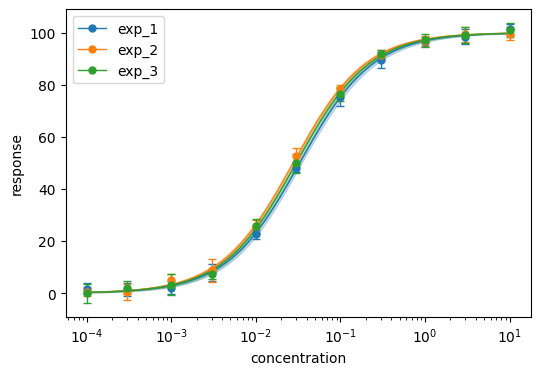

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_fits(ic50_data, ic50_results, ax=ax, confidence_band=True)
ax.set_xlabel("concentration")
ax.set_ylabel("response")
ax.legend()
plt.show()